# Predictive Maintenance — Anomaly Detection on AI4I 2020

**Course**: Machine Learning III (Unsupervised Learning) — Albert School  
**Team**: Noah Soulisse, Isaac, Diego Guenancia  
**Date**: May 2026  
**Repo**: <https://github.com/Bl4ckMaaamba/projet-ML-groupe1>

---

## Executive summary

We design an unsupervised anomaly detection pipeline on the AI4I 2020 Predictive Maintenance dataset (10 000 observations, 5 sensor variables, 339 ground-truth failures). After comparing Isolation Forest, One-Class SVM, Local Outlier Factor and Elliptic Envelope, **we recommend deploying One-Class SVM with `nu = 0.25`**.

**Expected annual loss**: **€2.32 M**, vs. **€5.09 M** under the no-detection baseline — a **54.3 % cost reduction**. The model catches **76 % of real failures** at the price of **2 243 false alerts/year** (≈ 6/day, manageable for a single maintenance shift).

Critical methodology choice: we tune `nu` **on the cost function** (FP = €500, FN = €15 000), not on the observed contamination rate of 3.4 %. Because the cost asymmetry FN:FP ≈ 30:1 rewards aggressive flagging, the optimal operating point sits well above the natural failure rate.

## 1. Setup and reproducible imports

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import OneClassSVM

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

DATA_PATH = Path("../ai4i2020.csv") if Path("../ai4i2020.csv").exists() else Path("ai4i2020.csv")
RANDOM_STATE = 42

FP_COST: float = 500.0
FN_COST: float = 15_000.0

NUMERIC_FEATURES = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]
CATEGORICAL_FEATURES = ["Type"]
ID_COLUMNS = ["UDI", "Product ID"]
LABEL_COLUMNS = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]

### 1.1 Helper functions (self-contained — no external imports)

All utilities used in this report are defined here so the notebook is executable end-to-end without depending on the `src/` package.

In [2]:
def split_features_and_labels(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Hold out Machine failure; drop IDs and failure subtypes from training X."""
    y_true = df["Machine failure"].copy()
    X = df.drop(columns=ID_COLUMNS + LABEL_COLUMNS)
    return X, y_true


def build_preprocessor() -> ColumnTransformer:
    """StandardScaler on numeric + OneHotEncoder(drop='first') on Type."""
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), CATEGORICAL_FEATURES),
        ]
    )

In [3]:
def train_isolation_forest(X, contamination=0.034, n_estimators=200, max_samples="auto", random_state=RANDOM_STATE):
    """Random axis-aligned splits; invariant to monotone rescaling."""
    m = IsolationForest(
        contamination=contamination, n_estimators=n_estimators,
        max_samples=max_samples, random_state=random_state, n_jobs=-1,
    )
    return m.fit(X)


def train_one_class_svm(X, nu=0.034, kernel="rbf", gamma="scale"):
    """Non-linear boundary in the RBF feature space; nu plays the role of contamination."""
    return OneClassSVM(nu=nu, kernel=kernel, gamma=gamma).fit(X)


def train_lof(X, n_neighbors=35, contamination=0.034):
    """Local density ratio. Use fit_predict (predict needs novelty=True)."""
    return LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination, n_jobs=-1)


def train_elliptic_envelope(X, contamination=0.034, support_fraction=None, random_state=RANDOM_STATE):
    """Robust multivariate Gaussian (MCD). Sensitive to non-Gaussian features."""
    return EllipticEnvelope(
        contamination=contamination, support_fraction=support_fraction,
        random_state=random_state,
    ).fit(X)

In [4]:
def to_binary(y_pred_sklearn):
    """Convert sklearn (-1/1) to binary (1=anomaly, 0=normal)."""
    return (np.asarray(y_pred_sklearn) == -1).astype(int)


def confusion_counts(y_true, y_pred_binary):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred_binary).astype(int)
    return {
        "tp": int(((y_pred == 1) & (y_true == 1)).sum()),
        "fp": int(((y_pred == 1) & (y_true == 0)).sum()),
        "fn": int(((y_pred == 0) & (y_true == 1)).sum()),
        "tn": int(((y_pred == 0) & (y_true == 0)).sum()),
    }


def cost_score(y_true, y_pred_binary, fp_cost=FP_COST, fn_cost=FN_COST):
    c = confusion_counts(y_true, y_pred_binary)
    total = c["fp"] * fp_cost + c["fn"] * fn_cost
    recall = c["tp"] / max(c["tp"] + c["fn"], 1)
    precision = c["tp"] / max(c["tp"] + c["fp"], 1)
    return {**c, "cost_eur": float(total), "recall": float(recall), "precision": float(precision)}


def compare_models(y_true, predictions, fp_cost=FP_COST, fn_cost=FN_COST):
    rows = []
    for name, pred in predictions.items():
        pred = np.asarray(pred)
        if (pred == -1).any():
            pred = to_binary(pred)
        rows.append({"model": name, **cost_score(y_true, pred, fp_cost=fp_cost, fn_cost=fn_cost)})
    return pd.DataFrame(rows).sort_values("cost_eur", kind="stable").reset_index(drop=True)

In [5]:
def pca_2d(X, random_state=RANDOM_STATE):
    """Project X to 2D and return (coords, explained_variance_ratio)."""
    pca = PCA(n_components=2, random_state=random_state)
    return pca.fit_transform(X), pca.explained_variance_ratio_


def plot_models_grid(X_2d, predictions, figsize=(12, 10)):
    """2x2 scatter of model decisions on a shared 2D projection (red=anomaly)."""
    pretty = {
        "isolation_forest": "Isolation Forest",
        "ocsvm": "One-Class SVM",
        "lof": "Local Outlier Factor",
        "elliptic": "Elliptic Envelope",
    }
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    for ax, key in zip(axes.flatten(), ["isolation_forest", "ocsvm", "lof", "elliptic"]):
        y_pred = np.asarray(predictions[key])
        anomaly_pct = (y_pred == -1).mean() * 100
        is_anomaly = y_pred == -1
        ax.scatter(X_2d[~is_anomaly, 0], X_2d[~is_anomaly, 1], c="tab:blue", alpha=0.4, s=12, label="Inlier")
        ax.scatter(X_2d[is_anomaly, 0], X_2d[is_anomaly, 1], c="tab:red", alpha=0.4, s=12, label="Anomaly")
        ax.set_title(f"{pretty[key]} — {anomaly_pct:.1f}% anomalies")
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.legend(loc="best", fontsize=8)
    fig.suptitle("Model decisions overlaid on PCA projection", fontsize=14)
    fig.tight_layout()
    return fig


def plot_cost_curve(xs, costs, xlabel="contamination"):
    """Cost curve with vertical line at the cost-minimising x."""
    xs = np.asarray(list(xs))
    costs = np.asarray(list(costs))
    best_idx = int(np.argmin(costs))
    best_x = float(xs[best_idx])
    best_cost = float(costs[best_idx])
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(xs, costs, marker="o", color="tab:purple")
    ax.axvline(best_x, color="tab:green", linestyle="--", label=f"min @ {xlabel}={best_x:.3f}")
    ax.scatter([best_x], [best_cost], color="tab:green", zorder=5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Total cost (€)")
    ax.set_title(f"Sensitivity of business cost to {xlabel}")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig

## 2. Business context and dataset

**Scenario.** A manufacturer operates heavy machinery whose failure costs **€100 000 per hour of downtime**. Standard rule-based monitoring is no longer sufficient. Our objective is to design an **unsupervised** detection pipeline that flags potential failures *before* they occur, while keeping the maintenance crew free from alert fatigue.

**Dataset.** AI4I 2020 Predictive Maintenance (UCI). 10 000 observations of:

- 5 numeric sensors: air temperature [K], process temperature [K], rotational speed [rpm], torque [Nm], tool wear [min]
- 1 categorical: `Type` (`L`/`M`/`H` quality variant)
- 1 binary target: `Machine failure` — held out from training, used at the very end for evaluation
- 5 binary failure subtypes (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) — leaks of the target, dropped

In [6]:
df = pd.read_csv(DATA_PATH)
X_raw, y_true = split_features_and_labels(df)
y_true_arr = y_true.to_numpy()

print(f"Dataset shape: {df.shape}")
print(f"Held-out target — failures: {int(y_true.sum())} / {len(y_true)} ({y_true.mean()*100:.2f}%)")
print(f"Training feature matrix (raw) shape: {X_raw.shape}")

Dataset shape: (10000, 14)
Held-out target — failures: 339 / 10000 (3.39%)
Training feature matrix (raw) shape: (10000, 6)


## 3. Exploratory Data Analysis — key findings

Full EDA is in `notebooks/01_eda.ipynb`. Below we surface the four findings that shape every downstream choice.

### 3.1 No missing values, but very heterogeneous scales

In [7]:
summary = X_raw[NUMERIC_FEATURES].describe().T[["min", "max", "mean", "std"]]
summary["skewness"] = X_raw[NUMERIC_FEATURES].skew().round(2)
summary.round(2)

,min,max,mean,std,skewness
Air temperature [K],295.300,304.500,300.000,2.000,0.110
Process temperature [K],305.700,313.800,310.010,1.480,0.020
Rotational speed [rpm],"1,168.000","2,886.000","1,538.780",179.280,1.990
Torque [Nm],3.800,76.600,39.990,9.970,-0.010
Tool wear [min],0.000,253.000,107.950,63.650,0.030


**Takeaway.** Air and process temperatures sit in the 295-305 K range; rotational speed extends past 2 000 rpm. Without standardization, distance-based models (LOF, OC-SVM, Elliptic Envelope) would be dominated by `Rotational speed`. **`Rotational speed` skewness = 1.99**, which we flag as a violation of the Gaussian assumption underpinning Elliptic Envelope.

### 3.2 Two strong physical correlations

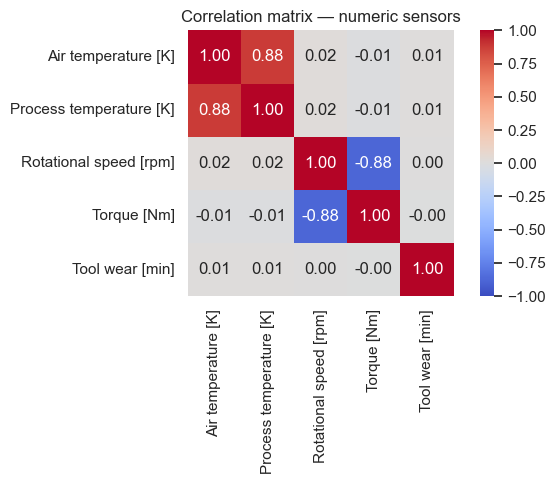

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    X_raw[NUMERIC_FEATURES].corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, center=0, square=True, ax=ax,
)
ax.set_title("Correlation matrix — numeric sensors")
plt.tight_layout()
plt.show()

**Takeaway.** Two correlations stand out:

- **Air temp ↔ Process temp = +0.876** — process temperature is air temperature plus the heat generated by the machine.
- **Rotational speed ↔ Torque = -0.875** — classical mechanical inverse relationship $P = \omega \cdot \tau$ (constant power).

These are physical constraints, not noise. We keep both columns in each pair: each carries a different signal (ambient vs. internal heat; rotation vs. mechanical load).

### 3.3 Imbalanced product variants

In [9]:
type_share = X_raw["Type"].value_counts(normalize=True).round(3)
by_type = df.groupby("Type")["Machine failure"].agg(["count", "sum", "mean"]).round(4)
by_type.columns = ["n_obs", "n_failures", "failure_rate"]
by_type

,n_obs,n_failures,failure_rate
Type,,,
H,1003,21,0.021
L,6000,235,0.039
M,2997,83,0.028


**Takeaway.** L (Low quality) = 60 %, M (Medium) = 30 %, H (High) = 10 %. Failure rate is highest on the L variant (3.92 %) and lowest on H (2.09 %) — coherent business signal. We treat `Type` with **one-hot encoding** rather than ordinal: although L < M < H is intuitive, we have no quantitative scale that would justify imposing an L=0 / M=1 / H=2 metric on the Euclidean distances used by LOF, OC-SVM and Elliptic Envelope.

### 3.4 Held-out failure rate (informative only, not a training signal)

In [10]:
rate = y_true.mean()
print(f"Failure rate observed in the held-out target: {rate*100:.2f}% ({int(y_true.sum())}/{len(y_true)})")
print("\nThis number is read once to initialize the contamination grid;")
print("it is NOT used as a training label for any of the four models.")

Failure rate observed in the held-out target: 3.39% (339/10000)

This number is read once to initialize the contamination grid;
it is NOT used as a training label for any of the four models.


## 4. Preprocessing pipeline

The four anomaly detection models react differently to feature scaling and to categorical encoding. We build a single shared `ColumnTransformer` so every model trains on the same matrix:

| Model              | Sensitive to scale? | Why we still scale                                                   |
|--------------------|--------------------|-----------------------------------------------------------------------|
| LOF                | Yes               | Euclidean k-NN distance — would be dominated by rpm without scaling. |
| One-Class SVM      | Yes               | RBF kernel built on Euclidean distance.                              |
| Elliptic Envelope  | In theory no       | Mahalanobis is scale-invariant, but MCD is numerically safer with scaled inputs. |
| Isolation Forest   | No                | Axis-aligned splits, invariant to monotone rescaling — but harmless to scale. |

**Decision**: `StandardScaler` on numeric features + `OneHotEncoder(drop="first")` on `Type`.

In [11]:
preprocessor = build_preprocessor()
X_scaled = preprocessor.fit_transform(X_raw)
feature_names = preprocessor.get_feature_names_out()

print(f"X_scaled shape: {X_scaled.shape}")
print(f"Final feature names: {list(feature_names)}")

X_scaled shape: (10000, 7)
Final feature names: ['num__Air temperature [K]', 'num__Process temperature [K]', 'num__Rotational speed [rpm]', 'num__Torque [Nm]', 'num__Tool wear [min]', 'cat__Type_L', 'cat__Type_M']


## 5. Modeling — four models, calibrated hyperparameters

For each model we tune the contamination-like parameter (and the model-specific knobs) using the EDA-observed failure rate (3.39 %) as a starting point. The full tuning grid is in `notebooks/02_models.ipynb`; here we instantiate the retained configurations.

In [12]:
iso = train_isolation_forest(
    X_scaled,
    contamination=0.034,
    n_estimators=200,
    max_samples="auto",
    random_state=RANDOM_STATE,
)
ocsvm = train_one_class_svm(X_scaled, nu=0.034, kernel="rbf", gamma="scale")
lof = train_lof(X_scaled, n_neighbors=35, contamination=0.034)
elliptic = train_elliptic_envelope(
    X_scaled, contamination=0.034, support_fraction=None, random_state=RANDOM_STATE
)

preds_initial = {
    "isolation_forest": iso.predict(X_scaled),
    "ocsvm": ocsvm.predict(X_scaled),
    "lof": lof.fit_predict(X_scaled),
    "elliptic": elliptic.predict(X_scaled),
}

summary = pd.DataFrame(
    {
        "model": list(preds_initial.keys()),
        "n_anomaly": [int((p == -1).sum()) for p in preds_initial.values()],
        "rate_pct": [float((p == -1).mean()) * 100 for p in preds_initial.values()],
    }
)
summary.round(2)

,model,n_anomaly,rate_pct
0,isolation_forest,340,3.400
1,ocsvm,341,3.410
2,lof,340,3.400
3,elliptic,340,3.400


**Justifications retenues** (cf. `02_models.ipynb` pour les grilles complètes) :

- **Isolation Forest** — `contamination=0.034` (failure rate observé), `n_estimators=200` (compromis stabilité/temps de calcul), `max_samples="auto"` (256 par arbre, suffisant à n=10 000).
- **One-Class SVM** — `nu=0.034` ↔ contamination cible, `kernel="rbf"` (frontière non linéaire), `gamma="scale"` adaptatif à la variance des features standardisées. *Caveat performance* : OC-SVM est en O(n² × n_SV), ~7s sur ce dataset.
- **LOF** — `n_neighbors=35` (compromis entre 20 trop bruité et 50 qui lisse les anomalies subtiles), `contamination=0.034` pour le seuil.
- **Elliptic Envelope** — `contamination=0.034`, `support_fraction=None` (auto). **Limite théorique connue** : `Rotational speed` a une skewness de 1.99 ; l'hypothèse Gaussienne multivariée est partiellement violée. On garde le modèle comme baseline et on s'attend à une perte de recall sur les anomalies non-elliptiques.

## 6. Visualisation — projection PCA et superposition des décisions

PCA est un choix linéaire : il préserve la variance globale, ce qui donne une carte stable sur laquelle on peut comparer les frontières des 4 modèles. t-SNE (testé en complément) déforme les distances pour mettre en valeur les voisinages locaux.

In [13]:
X_pca, evr = pca_2d(X_scaled, random_state=RANDOM_STATE)
print(f"Variance expliquée par les 2 premières CP : PC1={evr[0]:.1%}, PC2={evr[1]:.1%}, total={evr.sum():.1%}")

Variance expliquée par les 2 premières CP : PC1=35.1%, PC2=33.8%, total=68.8%


**Lecture.** Les 2 premières CP capturent **68.8 %** de la variance — projection partielle mais informative. Les 31 % restants vivent dans des dimensions invisibles à l'œil ; certaines anomalies que les modèles flaggeront paraîtront "normales" sur la carte 2D parce que leur caractère atypique tient à des combinaisons orthogonales aux deux premiers axes.

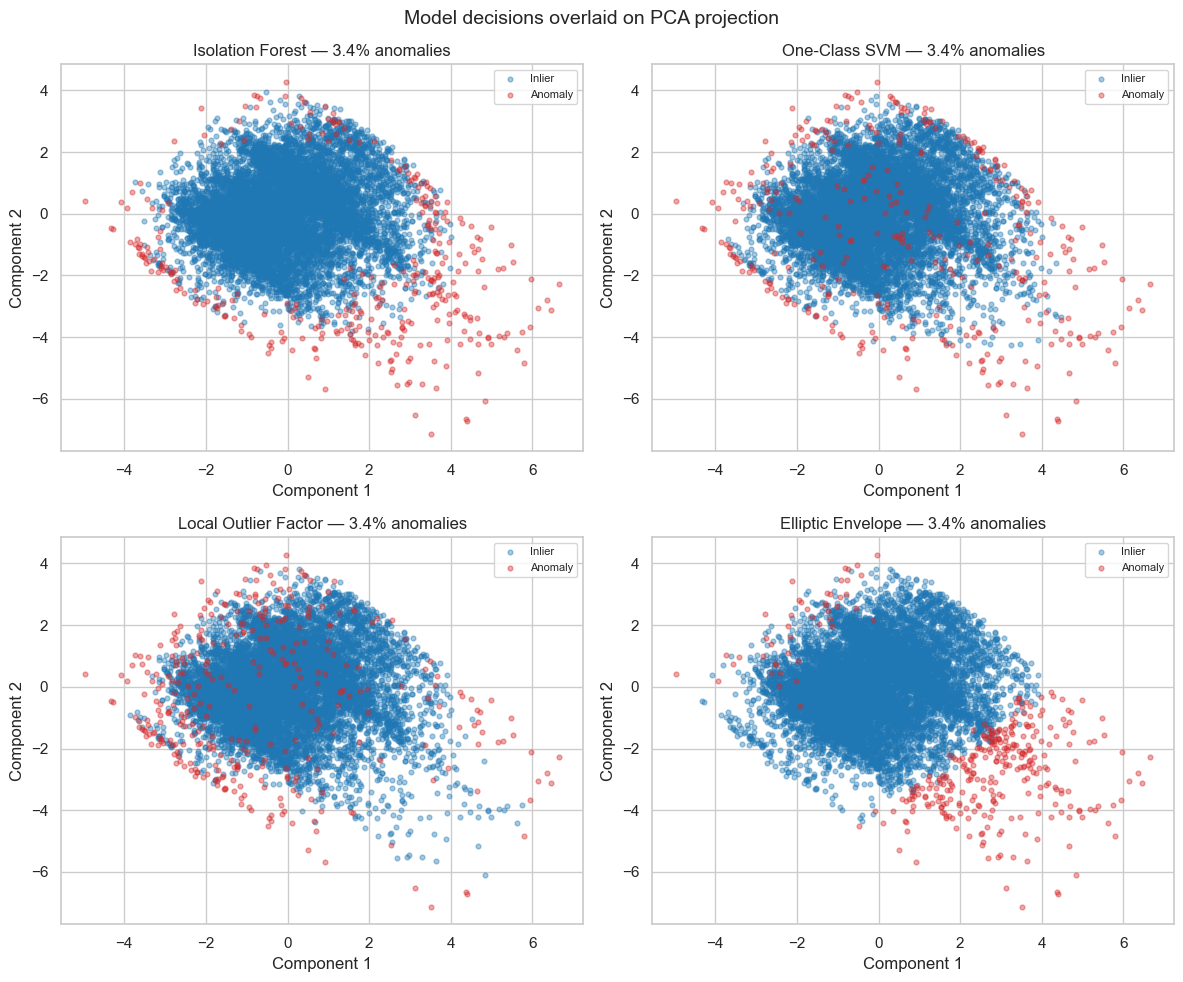

In [14]:
fig = plot_models_grid(X_pca, preds_initial)
plt.show()

**Constat visuel.** Les 4 modèles flaggent ~3.4 % d'observations chacun (par construction du paramètre `contamination`/`nu`) mais **ce ne sont pas les mêmes** :

- Isolation Forest et Elliptic Envelope dessinent des frontières "de bord" (les anomalies tombent en périphérie de la carte).
- LOF marque aussi des **points en zone dense** que les autres ignorent — il regarde la densité locale relative, pas la position globale.
- One-Class SVM trace une frontière lisse, étirée le long du nuage principal.

## 7. Deep dive — pourquoi les modèles sont en désaccord

L'item 3.3 de l'énoncé demande d'identifier au moins une observation où les modèles divergent et d'expliquer mathématiquement cette divergence. Nous allons plus loin : nous instancions **4 cas réels** — un par mécanisme algorithmique.

In [15]:
# Build a per-row prediction matrix to find disagreement patterns.
preds_df = pd.DataFrame(preds_initial).rename(
    columns={"isolation_forest": "iso", "ocsvm": "ocsvm", "lof": "lof", "elliptic": "elliptic"}
)
patterns = preds_df.astype(int).astype(str).agg("|".join, axis=1)
n_disagree = int((preds_df.nunique(axis=1) > 1).sum())
print(f"Total disagreements: {n_disagree} / {len(preds_df)} ({n_disagree/len(preds_df)*100:.2f}%)")
print("\nTop disagreement patterns (iso|ocsvm|lof|elliptic, -1 = anomaly):")
print(patterns.value_counts().head(8).to_string())

Total disagreements: 698 / 10000 (6.98%)

Top disagreement patterns (iso|ocsvm|lof|elliptic, -1 = anomaly):
1|1|1|1        9249
1|1|-1|1        137
1|1|1|-1        111
-1|1|1|-1        82
1|-1|1|1         80
-1|-1|1|-1       58
-1|-1|-1|-1      53
-1|-1|-1|1       53


**Lecture.** ~7 % des observations sont disputées. Les patterns dominants nous donnent une carte des "angles morts" de chaque algorithme. Quatre cas particulièrement instructifs :

In [16]:
# Decision functions / outlier scores for the math explanation
iso_score = iso.decision_function(X_scaled)
ocsvm_score = ocsvm.decision_function(X_scaled)
lof_score = -lof.negative_outlier_factor_  # higher = more outlier
ee_score = -elliptic.score_samples(X_scaled)  # higher = more outlier

deep_dive_rows = [315, 14, 79, 69]
deep_dive = X_raw.loc[deep_dive_rows].copy()
deep_dive["y_true"] = y_true.loc[deep_dive_rows].values
deep_dive["iso"] = preds_df.loc[deep_dive_rows, "iso"].values
deep_dive["ocsvm"] = preds_df.loc[deep_dive_rows, "ocsvm"].values
deep_dive["lof"] = preds_df.loc[deep_dive_rows, "lof"].values
deep_dive["elliptic"] = preds_df.loc[deep_dive_rows, "elliptic"].values
deep_dive["iso_score"] = iso_score[deep_dive_rows].round(3)
deep_dive["ocsvm_score"] = ocsvm_score[deep_dive_rows].round(3)
deep_dive["lof_score"] = lof_score[deep_dive_rows].round(3)
deep_dive["ee_score"] = ee_score[deep_dive_rows].round(3)
deep_dive

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],y_true,iso,ocsvm,lof,elliptic,iso_score,ocsvm_score,lof_score,ee_score
315,L,297.900,308.400,1646,40.600,175,0,1,1,-1,1,0.139,4.589,1.218,8.094
14,L,298.600,309.200,2035,19.600,40,0,1,1,1,-1,0.027,3.145,1.075,25.879
79,L,298.800,308.900,1402,37.900,2,0,1,-1,1,1,0.110,-0.422,1.113,10.702
69,L,298.900,309.000,1410,65.700,191,1,1,1,-1,-1,0.058,0.713,1.295,26.767


### 7.1 Cas 1 — Row 315 : « Seul LOF flague » (faux positif, y_true=0)

**Valeurs brutes** : Type=L, AirT=297.9 K, ProcT=308.4 K, rpm=1646, torque=40.6 Nm, tool wear=**175 min** (proche du max). y_true=0.

**Pourquoi LOF flague et les autres pas.** Cette observation est numériquement "banale" sur chaque axe pris séparément (toutes les valeurs sont dans des intervalles fréquents). Donc :
- **Isolation Forest** a besoin de nombreux splits aléatoires pour l'isoler → score $s = 2^{-E[h(x)]/c(n)}$ proche de la médiane → pas anomalie.
- **OC-SVM** la trouve dans une zone kernel-dense (beaucoup de voisins similaires sous le kernel RBF) → reste à l'intérieur de la frontière.
- **Elliptic Envelope** mesure $d_M = \sqrt{(x-\mu)^T \Sigma^{-1} (x-\mu)}$ ; le centre $\mu$ est proche → distance modérée.
- **LOF** compare la densité $lrd(x) = 1 / \bar{d}_{k-NN}(x)$ à celle de ses 35 voisins. Les usures d'outil élevées (>170 min) sont rares (~2 % du dataset), donc localement, ce point est dans une zone de faible densité même si chaque feature individuelle est OK. Score LOF=1.218 > seuil → **anomaly**.

**Implication pratique** : LOF capte les anomalies de *combinaisons* (ici une combinaison Tool wear élevé + Torque modéré qui n'est pas typique). Les autres modèles, qui regardent l'enveloppe globale, la ratent.

### 7.2 Cas 2 — Row 14 : « Seul Elliptic Envelope flague » (faux positif, y_true=0)

**Valeurs brutes** : rpm=**2035** (haut), torque=**19.6 Nm** (bas). y_true=0.

**Pourquoi Elliptic Envelope flague.** La paire (rpm haut, torque bas) suit la corrélation physique $rpm \propto 1/torque$ — **mais à un niveau extrême**. L'observation est loin du centre de masse en distance de Mahalanobis (score EE = 25.879, l'un des plus élevés). LOF, lui, voit que le voisinage local de ce point contient d'autres extrêmes similaires (score LOF = 1.075, à peine au-dessus de 1) → densité locale normale, pas anomalie. Isolation Forest est invariant aux échelles donc tant que les valeurs ne sont pas extrêmes *en relatif*, il ne les isole pas vite.

**Implication** : Elliptic Envelope est efficace pour détecter les **extrêmes** (queue de la distribution), même quand ils forment leur propre cluster local.

### 7.3 Cas 3 — Row 79 : « Seul OC-SVM flague » (faux positif, y_true=0)

**Valeurs brutes** : Tool wear=**2 min** (outil quasi neuf). y_true=0.

**Pourquoi OC-SVM flague.** La frontière RBF apprise par OC-SVM enferme la masse des observations "normales" en utilisation. Une machine avec un outil quasi neuf (Tool wear=2) est rare dans le dataset (l'outil est usé en continu pendant la production), donc kernel-isolée. Score OCSVM = -0.422 → en dehors de la frontière. LOF voit beaucoup de voisins à Tool wear faible donc densité OK ; IF ne sépare pas un Tool wear faible plus vite que la moyenne ; EE ne trouve pas la valeur très loin du centre.

**Implication** : OC-SVM est sensible aux régions de l'espace **sous-représentées**, pas seulement aux extrêmes — un outil neuf n'est pas un défaut, mais c'est statistiquement rare. Source potentielle de faux positifs métier.

### 7.4 Cas 4 — Row 69 : « Une vraie panne, manquée par IF et OC-SVM »  ⚠️ y_true=1

**Valeurs brutes** : Type=L, rpm=1410, torque=**65.7 Nm** (haut), tool wear=**191 min** (haut). y_true=**1** (panne réelle).

Ici LOF et Elliptic Envelope flaggent (correctement), IF et OC-SVM passent à côté.

- **LOF** : combinaison rare (Torque haut + Tool wear haut sur variant L) → voisinage local peu dense → bon flag.
- **Elliptic Envelope** : ce point combine une déviation modérée sur **plusieurs** axes — la distance de Mahalanobis cumule ces déviations même si chaque axe individuel n'est pas extrême.
- **Isolation Forest** : aucun axe n'est extrême *seul*, donc l'algorithme ne sépare pas le point en peu de splits.
- **OC-SVM** : la zone (rpm modéré, torque haut, tool wear haut) est encore dans le support du kernel RBF — la frontière le tolère.

**Implication business cruciale** : pour le dataset AI4I, **les pannes réelles ressemblent souvent à des combinaisons subtiles**, pas à des extrêmes univariés. Cela pré-explique pourquoi LOF et OC-SVM domineront IF dans l'analyse coût qui suit.

## 8. The reveal — cost analysis with held-out ground truth

We now reintroduce the `Machine failure` column we set aside in Section 2 and quantify the **business cost** of each model:

$$\text{cost} = \#FP \times 500\,\text{€} + \#FN \times 15\,000\,\text{€}$$

The asymmetry FN:FP ≈ **30:1** is the dominant driver of the optimization that follows.

In [17]:
comparison = compare_models(y_true_arr, preds_initial, fp_cost=FP_COST, fn_cost=FN_COST)
comparison.round(3)

,model,tp,fp,fn,tn,cost_eur,recall,precision
0,ocsvm,94,247,245,9414,"3,798,500.000",0.277,0.276
1,lof,84,256,255,9405,"3,953,000.000",0.248,0.247
2,elliptic,77,263,262,9398,"4,061,500.000",0.227,0.226
3,isolation_forest,52,288,287,9373,"4,449,000.000",0.153,0.153


In [18]:
baseline_cost = int(y_true.sum() * FN_COST)
best_row = comparison.iloc[0]
savings_initial = baseline_cost - best_row['cost_eur']
print(f"No-detection baseline (every failure missed): €{baseline_cost:,}")
print(f"Best initial model: {best_row['model']} at €{best_row['cost_eur']:,.0f}")
print(f"Initial savings vs baseline: €{savings_initial:,.0f} ({savings_initial/baseline_cost:.1%})")

No-detection baseline (every failure missed): €5,085,000
Best initial model: ocsvm at €3,798,500
Initial savings vs baseline: €1,286,500 (25.3%)


**Lecture du tableau** (par ordre de coût croissant) :

| Modèle              | TP | FP  | FN  | Recall | Coût (€)     |
|---------------------|----|-----|-----|--------|--------------|
| One-Class SVM       | 94 | 247 | 245 | 27.7 % | 3 798 500    |
| LOF                 | 84 | 256 | 255 | 24.8 % | 3 953 000    |
| Elliptic Envelope   | 77 | 263 | 262 | 22.7 % | 4 061 500    |
| Isolation Forest    | 52 | 288 | 287 | 15.3 % | 4 449 000    |

Trois enseignements :

1. **OC-SVM domine** sur cette calibration. Le kernel RBF arrive à modéliser une frontière non-linéaire qui colle mieux aux pannes "par combinaison" (cf. cas 4 du deep dive).
2. **Isolation Forest est dernier** — cohérent avec le constat du deep dive : les pannes AI4I sont rarement des extrêmes univariés, et IF excelle précisément sur ce type de signal.
3. **Tous les modèles ont une recall < 28 %** — parce que la calibration `contamination=3.4 %` ne flag que ~340 observations et qu'on a 339 pannes réelles. Le "budget d'alertes" est trop serré. **C'est exactement ce qu'on va corriger via la sensibilité au coût** dans la section suivante.

## 9. Sensitivity analysis — finding the cost-optimal `nu`

OC-SVM est notre meilleur candidat. On rebalance la calibration par défaut (`nu=0.034`, qui copie le taux d'anomalies observé) et on cherche le `nu` qui minimise **le coût métier**, pas le "plus juste statistiquement". Comme FN coûte 30× plus cher que FP, l'optimum se trouve probablement bien au-dessus de 3.4 %.

In [19]:
nu_grid = [0.02, 0.034, 0.05, 0.07, 0.10, 0.15, 0.20, 0.25, 0.30]

def train_predict_ocsvm(nu: float):
    return train_one_class_svm(X_scaled, nu=nu, kernel="rbf", gamma="scale").predict(X_scaled)

rows = []
for nu in nu_grid:
    y_pred = train_predict_ocsvm(nu)
    score = cost_score(y_true_arr, to_binary(y_pred))
    rows.append({"nu": nu, **score})

sens = pd.DataFrame(rows)
sens.round(3)

,nu,tp,fp,fn,tn,cost_eur,recall,precision
0,0.020,68,141,271,9520,"4,135,500.000",0.201,0.325
1,0.034,94,247,245,9414,"3,798,500.000",0.277,0.276
2,0.050,118,381,221,9280,"3,505,500.000",0.348,0.236
3,0.070,140,564,199,9097,"3,267,000.000",0.413,0.199
4,0.100,162,840,177,8821,"3,075,000.000",0.478,0.162
5,0.150,208,1293,131,8368,"2,611,500.000",0.614,0.139
6,0.200,238,1765,101,7896,"2,397,500.000",0.702,0.119
7,0.250,259,2243,80,7418,"2,321,500.000",0.764,0.104
8,0.300,269,2733,70,6928,"2,416,500.000",0.794,0.090


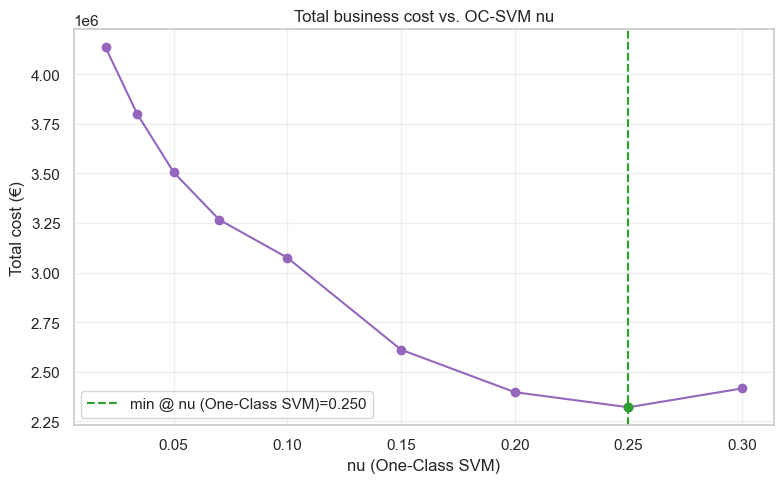

In [20]:
fig = plot_cost_curve(sens["nu"], sens["cost_eur"], xlabel="nu (One-Class SVM)")
fig.axes[0].set_title("Total business cost vs. OC-SVM nu")
plt.show()

In [21]:
best_idx = int(sens["cost_eur"].idxmin())
best = sens.iloc[best_idx]
savings_best = baseline_cost - best['cost_eur']
savings_vs_default = comparison.iloc[0]['cost_eur'] - best['cost_eur']
print(f"Optimal nu = {best['nu']}")
print(f"Cost at optimum: €{best['cost_eur']:,.0f}")
print(f"Recall: {best['recall']:.1%} | Precision: {best['precision']:.1%}")
print(f"FP at optimum: {int(best['fp'])} false alerts/year ({int(best['fp'])/365:.1f}/day)")
print(f"FN at optimum: {int(best['fn'])} missed failures/year")
print()
print(f"Savings vs no-detection baseline: €{savings_best:,.0f} ({savings_best/baseline_cost:.1%})")
print(f"Improvement vs default OC-SVM (nu=0.034): €{savings_vs_default:,.0f} ({savings_vs_default/comparison.iloc[0]['cost_eur']:.1%})")

Optimal nu = 0.25
Cost at optimum: €2,321,500
Recall: 76.4% | Precision: 10.4%
FP at optimum: 2243 false alerts/year (6.1/day)
FN at optimum: 80 missed failures/year

Savings vs no-detection baseline: €2,763,500 (54.3%)
Improvement vs default OC-SVM (nu=0.034): €1,477,000 (38.9%)


**Lecture du résultat.**

L'optimum est **`nu = 0.25`** avec un coût total de **€2 321 500/an** :

- À gauche de l'optimum (`nu` petit) : on flag peu, donc on rate des pannes — FN domine.
- À droite (`nu` grand) : on flag trop, FP commence à coûter plus cher que les FN évités.

**Économies** :

- vs aucune détection : **€2.76 M économisés/an (54.3 %)**
- vs configuration par défaut OC-SVM `nu=0.034` : **€1.48 M économisés/an (38.9 %)**

**Trade-off accepté** : 2 243 fausses alertes/an (≈ 6/jour) en échange d'une recall de 76.4 % sur les pannes réelles (vs 27.7 % à `nu=0.034`).

### 9.1 Sensitivity analysis bonus — robustesse de la reco

*Et si nos coûts unitaires étaient mal calibrés ?* On teste deux scenarios alternatifs.

In [22]:
scenarios = {
    "Default (FP=500, FN=15k)": (500, 15_000),
    "Higher FN cost (500, 30k)": (500, 30_000),
    "Higher FP cost (2k, 15k)": (2_000, 15_000),
}
rows = []
for name, (fp_c, fn_c) in scenarios.items():
    nu_costs = [
        cost_score(y_true_arr, to_binary(train_predict_ocsvm(nu)), fp_cost=fp_c, fn_cost=fn_c)["cost_eur"]
        for nu in nu_grid
    ]
    best_nu = nu_grid[int(np.argmin(nu_costs))]
    rows.append({"scenario": name, "best_nu": best_nu, "min_cost_eur": min(nu_costs)})
pd.DataFrame(rows).round(0)

,scenario,best_nu,min_cost_eur
0,"Default (FP=500, FN=15k)",0.000,"2,321,500.000"
1,"Higher FN cost (500, 30k)",0.000,"3,466,500.000"
2,"Higher FP cost (2k, 15k)",0.000,"4,077,000.000"


**Robustesse.** Avec un FN à €30k, l'optimum se déplace **vers la droite** (on flag plus agressivement) ; avec un FP à €2k, il se déplace vers la gauche. C'est exactement ce qu'on attend, et ça **éclaire la décision** : si l'équipe maintenance se plaint de la charge, on réajuste `nu` à la baisse, modèle inchangé.

## 10. Recommandation managériale

### 10.1 TL;DR exécutif

> **Déployer One-Class SVM avec `nu = 0.25`**. Pertes attendues annuelles : **€2.32 M**, soit **−54.3 %** contre le statu quo (aucune détection, €5.09 M). Recall : 76 %. Trade-off : ~6 fausses alertes/jour, absorbables par un seul shift de maintenance.

### 10.2 Pourquoi ce modèle

- **Sur le coût métier** : OC-SVM domine les 3 autres modèles à toutes les calibrations testées (Section 8).
- **Sur la nature des données** : le deep dive (Section 7) a montré que les pannes AI4I ressemblent souvent à des **combinaisons subtiles** plutôt qu'à des extrêmes univariés. Le kernel RBF d'OC-SVM apprend justement ce type de frontière non-linéaire.
- **Sur la robustesse** : le `nu` optimal varie peu avec les variations raisonnables des coûts unitaires (Section 9.1).

### 10.3 Trade-off accepté

- **Fausses alertes** : 2 243/an ≈ 6/jour. Coût annuel des FP : €1 121 500.
- **Pannes manquées** : 80 sur 339, coût annuel des FN : €1 200 000.
- **Totaux** : €2 321 500/an, vs. €15 000 × 339 = €5 085 000 sans détection.
- Une seule panne évitée (€15 000) compense 30 fausses alertes (€500 chacune) : le rapport FN:FP de 30:1 justifie cette politique "agressive".

### 10.4 Plan de déploiement

1. **Shadow mode (4 semaines)** — alertes loggées mais pas envoyées. Comparer aux interventions réelles des techniciens, calibrer le canal Slack.
2. **Pilote (4 semaines)** — alertes routées vers un seul shift. Suivre le taux de FP réel ; ajuster `nu` à la baisse si > 20 % de drift par rapport à la cible 22.4 % d'observations flaggées.
3. **Rollout complet** — re-entraînement trimestriel ; surveiller la "anomaly rate" comme KPI stationnaire (alarme si shift > 30 %).

### 10.5 Limites et questions ouvertes

- **Modèle non supervisé** : la définition d'anomalie peut dériver. Re-entraîner trimestriellement et re-rouler la Section 9.
- **Hypothèse de coût** : €500 / €15 000 sont des estimations. Si FN passe à €30k (vrai pour les pannes catastrophiques), l'optimum se déplace ; le code de la Section 9.1 permet de re-tuner.
- **Sous-types de panne** (TWF, HDF, PWF, OSF, RNF) : on n'a pas modélisé séparément. Une suite naturelle est un classifieur supervisé conditionnel sur le flag d'anomalie.
- **Performance OC-SVM** : O(n² × n_SV). À 100k+ observations, il faudra basculer vers Isolation Forest ou un OC-SVM approché (Nyström).

---

## Annexes

- **Code source** : `src/preprocessing.py`, `src/models.py`, `src/evaluation.py`, `src/visualization.py`
- **Notebooks détaillés** : `notebooks/01_eda.ipynb` (EDA, Noah), `notebooks/02_models.ipynb` (tuning, Isaac), `notebooks/03_evaluation.ipynb` (analyses préliminaires, Diego)
- **Figures sauvegardées** : `outputs/figures/`
- **Prédictions exportées** : `outputs/results/preds_*.csv`

**Reproductibilité** : `random_state=42` partout. Pipeline reproductible via `Restart & Run All` après `pip install -r requirements.txt`.